# Disag with light

## Model possibilities

Reference model: Plain LSTM (raw time-series)

Variant 1: OvO ensemble (linear MLPs) (sliding window against FFT info)

Variant 2: Hybrid CNN-LSTM (

## Imports and defs

In [212]:
import importlib
from joblib import Parallel, delayed
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import random
import scripts
import torch

from IPython.display import Image, display

DataLoader = torch.utils.data.DataLoader
ConcatDataset = torch.utils.data.ConcatDataset
optim = torch.optim
nn = torch.nn

# force reload of scripts module:
importlib.reload(scripts) # this is fine for modules without dependencies
from scripts import (
    count_num_samples,
    downsample_with_pandas,
    get_micro_dataset,
    get_sample_rate,
    get_target_devices,
    FastNILMDataset,
    load_yaml,
    save_yaml
)

torch.manual_seed(120)
random.seed(42)
Device = None
if torch.cuda.is_available():
    Device = 'cuda'
elif torch.backends.mps.is_available():
    Device = 'mps'
else:
    Device = 'cpu'

print(f'Device is {Device}')

%matplotlib inline

Device is cuda


### Model defs

In [187]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=4):
        super(BaselineLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # The LSTM layer
        # batch_first=True means inputs should be (batch_size, sequence_length, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # A fully connected layer to map the LSTM hidden state to our device classes
        self.fc = nn.Linear(hidden_size, num_classes)

        # # Sigmoid for multi-label classification (outputs probabilities between 0 and 1)
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the LAST time step in the window
        out = out[:, -1, :]
        out = self.fc(out)
        # out = self.sigmoid(out)

        return out


In [188]:
desc_files = [ f for f in os.listdir("data") if f.startswith("desc_") ]
event_files_with_descs = [ os.path.splitext("events_"+f[len('desc_'):])[0] + '.csv' for f in desc_files ]
total_event_count = 0
for f in event_files_with_descs:
    f_full = os.path.join('data',f)
    if not os.path.isfile(f_full):
        print(f"File expected at {f_full} does not exist or exist yet.")
        continue
    event_count = count_num_samples(f_full)
    print(f"{f} has {event_count} events.")
    total_event_count += event_count
print(f"Total events: {total_event_count}")

events_20260501_003252_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last.csv has 2 events.
events_20260501_003902_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_004409_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_004918_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_010248_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_013851_incandescent_3-device_tango_15000_hz.csv has 20 events.
events_20260501_015332_incandescent_3-device_waltz_10000_hz.csv has 30 events.
events_20260501_021140_incandescent_4-device_mamba_10000_hz.csv has 32 events.
events_20260501_023148_incandescent_4-device_serenade_20000_hz.csv has 40 events.
events_20260501_024855_cfl_4-device_cha_cha_20000_hz.csv has 39 events.
events_20260501_

## Downsampling test:

Sample rate: 50000
Processed chunk...
Processed chunk...


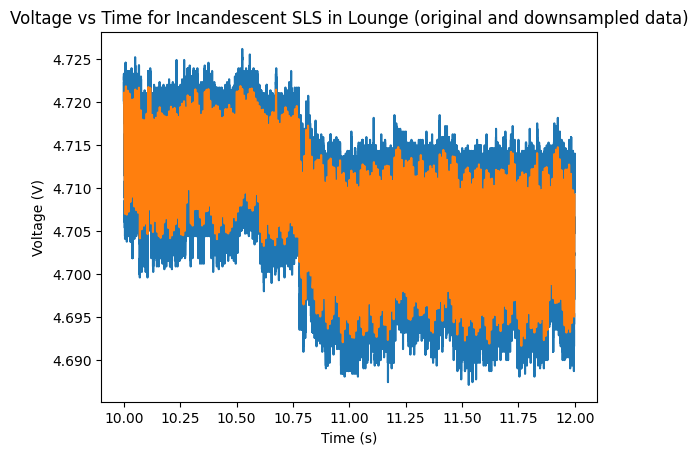

In [189]:
file_name = "data/light_20260430_211842_incandescent_sls_in_lounge_50000_hz.csv"
# file_name = "data/light_20260401_163627.csv"

sample_rate = get_sample_rate(file_name)
print(f"Sample rate: {sample_rate}")

sample1 = downsample_with_pandas(file_name, 1, skip_seconds=10, n_seconds=2)
sample2 = downsample_with_pandas(file_name, 100, skip_seconds=10, n_seconds=2)

plt.plot(sample1['elapsed_s'], sample1['voltage_V'])
plt.plot(sample2['elapsed_s'], sample2['voltage_V'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time for Incandescent SLS in Lounge (original and downsampled data)')
plt.show()


In [190]:
#STRIPME

pd.read_csv("data/events_20260501_034916_led_4-device_speedwalk_10000_hz.csv", nrows=20)

,sample_index,elapsed_s,label
0,141000,14.1,space_heater_on
1,246000,24.6,space_heater_off
2,300000,30.0,fridge_on
3,605000,60.5,fridge_off
4,859000,85.9,kettle_on
5,904000,90.4,kettle_off
6,928000,92.8,sls_on
7,2132000,213.2,sls_off


## Data preprocessing setup

In [191]:
def generate_state_matrix(voltage_df, events_df, target_devices):
    """Calculates the continuous 1s, 0s, and -1s (uncertainty) state matrix."""
    state_matrix = np.zeros((len(voltage_df), len(target_devices)), dtype=np.float32)
    current_state = {dev: 0.0 for dev in target_devices}
    uncertain_until = {dev: 0.0 for dev in target_devices}
    UNCERTAINTY_WINDOW = 30.0

    event_idx = 0
    num_events = len(events_df)

    for i, elapsed_s in enumerate(voltage_df['elapsed_s'].values):
        while event_idx < num_events and elapsed_s >= events_df.iloc[event_idx]['elapsed_s']:
            event_str = events_df.iloc[event_idx]['label']
            event_time = events_df.iloc[event_idx]['elapsed_s']

            for dev in target_devices:
                if dev in event_str:
                    if "_on" in event_str:
                        # ONLY the fridge gets the 30-second uncertainty window
                        if dev == 'fridge':
                            current_state[dev] = -1.0
                            uncertain_until[dev] = event_time + UNCERTAINTY_WINDOW
                        else:
                            # Everything else turns ON instantly
                            current_state[dev] = 1.0
                            uncertain_until[dev] = 0.0

                    elif "_off" in event_str:
                        current_state[dev] = 0.0
                        uncertain_until[dev] = 0.0
            event_idx += 1

        # Check if the fridge's uncertainty window has passed
        for dev in target_devices:
            if current_state[dev] == -1.0 and elapsed_s >= uncertain_until[dev]:
                current_state[dev] = 1.0

        for dev_idx, dev in enumerate(target_devices):
            state_matrix[i, dev_idx] = current_state[dev]

    return state_matrix


def _process_single_file(desc_f, data_dir, output_dir, target_hz, force_rebuild, global_devices):
    base_suffix = os.path.splitext(desc_f[len('desc_'):])[0]
    out_path = os.path.join(output_dir, f"{base_suffix}.npz")

    # --- THE NO-OP CHECK ---
    if os.path.exists(out_path) and not force_rebuild:
        return f"[~] Skipping {base_suffix}: Already preprocessed."

    event_full = os.path.join(data_dir, f"events_{base_suffix}.csv")
    light_full = os.path.join(data_dir, f"light_{base_suffix}.csv")

    if not (os.path.isfile(event_full) and os.path.isfile(light_full)):
        return f"[-] Skipping {base_suffix}: Missing CSVs."
    if count_num_samples(event_full, harsh=False) == 0:
        return f"[-] Skipping {base_suffix}: 0 events."

    # Downsample
    native_hz = get_sample_rate(light_full)
    dynamic_factor = max(1, native_hz // target_hz)
    voltage_df = downsample_with_pandas(input_file=light_full, factor=dynamic_factor)
    events_df = pd.read_csv(event_full)

    # Calculate matrix
    state_matrix = generate_state_matrix(voltage_df, events_df, global_devices)

    # Save as highly compressed binary NumPy format
    np.savez_compressed(
        out_path,
        voltage=voltage_df['voltage_V'].values,
        states=state_matrix,
        devices=global_devices
    )
    print(f"[+] Processed and saved: {base_suffix}.npz")


def compile_datasets(data_dir="data", output_dir="preprocess_cache", target_hz=100, force_rebuild=False, ignore_list=['lamp']):
    """ ignore_list  --  devices to ignore by key from devices.json We ignore
                         the lamp by default because although it has load
                         characateristics, it's currently going to appear in
                         every experiment because it's needed for the sensor
    """
    os.makedirs(output_dir, exist_ok=True)

    # 1. Global Devices
    desc_files = [f for f in os.listdir(data_dir) if f.startswith("desc_") and f.endswith(".json")]
    global_devices = set()
    for f in desc_files:
        devices = get_target_devices(os.path.join(data_dir, f))
        global_devices.update(devices)
    global_devices = sorted(list(global_devices))

    for ignore_dev in ignore_list:
        if ignore_dev in global_devices:
            global_devices.remove(ignore_dev)

    print(f"Global Targets: {global_devices}")
    print(f"Starting parallel processing of {len(desc_files)} files using Joblib...")

    # 2. Execute parallel pool!
    # n_jobs=-1 tells it to use all available CPU cores.
    results = Parallel(n_jobs=-1, return_as='generator')(
        delayed(_process_single_file)(
            desc_f, data_dir, output_dir, target_hz, force_rebuild, global_devices
        ) for desc_f in desc_files
    )

    print("\n[*] Preprocessing complete.")




## Data preprocessing

In [192]:
downsample_target_hz = 100
compile_datasets(force_rebuild=False, target_hz=downsample_target_hz)

Global Targets: ['dell', 'fridge', 'kettle', 'sls', 'space_heater']
Starting parallel processing of 41 files using Joblib...

[*] Preprocessing complete.


C:\repos\disag-with-light\.venv\Lib\site-packages\joblib\parallel.py:1886: UserWarning: 16 tasks which were still being processed by the workers have been cancelled. You could benefit from adjusting the input task iterator to limit unnecessary computation time.
  warnings.warn(msg)


## Training setup

### Data loading setup

In [193]:
def load_fast_datasets(preprocess_dir="preprocess_cache", window_size=200, specific_files=None, specific_files_invert=False, shuffle=True, train_ratio=0.8):
    """ specific_files  --  process a specific list of files instead of a directory """
    def concat(filenames, is_train=False):
        if not filenames:
            return None
        datasets = []
        for f in filenames:
            ffull = os.path.join(preprocess_dir, f)
            datasets.append(FastNILMDataset(ffull, window_size=window_size, build_stats=is_train))
        return ConcatDataset(datasets)

    if specific_files and not specific_files_invert:
        npz_files = specific_files
    else:
        npz_files = [
        f for f in os.listdir(preprocess_dir) if
            f.endswith(".npz")
    ]
        if specific_files_invert:
            npz_files = [ f for f in npz_files if f not in specific_files ]
    if shuffle:
        random.shuffle(npz_files)

    # Load the devices array from the first file so we know what they are
    sample_data = np.load(os.path.join(preprocess_dir, npz_files[0]))
    classes = sample_data['devices']

    # Employ stratified split aross labels so we don't wind up with none:
    if train_ratio == 1.0:
        train_files, test_files = list(npz_files), []
    elif train_ratio == 0.0:
        train_files, test_files = [], list(npz_files)
    else:
        # 1. Map out which devices are active in which files
        device_to_files = {dev: [] for dev in classes}
        for f in npz_files:
            data = np.load(os.path.join(preprocess_dir, f))
            states = data['states']

            # Sum down time axis. If sum > 0, device turned ON at least once.
            active_cols = np.where(states.sum(axis=0) > 0)[0]
            for col in active_cols:
                device_to_files[classes[col]].append(f)

        train_files_set = set()
        test_files_set = set()

        # 2. Guarantee at least one file per device in BOTH sets
        for dev, files in device_to_files.items():
            if len(files) == 0:
                continue
            elif len(files) == 1:
                # If a device is only in ONE file globally, force it into Train
                train_files_set.add(files[0])
            else:
                # Ensure Train gets one
                if not any(f in train_files_set for f in files):
                    unassigned = [f for f in files if f not in train_files_set and f not in test_files_set]
                    if unassigned: train_files_set.add(unassigned.pop())

                # Ensure Test gets one
                if not any(f in test_files_set for f in files):
                    unassigned = [f for f in files if f not in train_files_set and f not in test_files_set]
                    if unassigned: test_files_set.add(unassigned.pop())

        # 3. Fill the rest of the files to match the requested train_ratio
        all_assigned = train_files_set.union(test_files_set)
        remaining = [f for f in npz_files if f not in all_assigned]

        target_train_count = int(len(npz_files) * train_ratio)
        needed_for_train = target_train_count - len(train_files_set)

        for f in remaining:
            if needed_for_train > 0:
                train_files_set.add(f)
                needed_for_train -= 1
            else:
                test_files_set.add(f)

        train_files = list(train_files_set)
        test_files = list(test_files_set)
    # =================================================================

    train_master = concat(train_files, is_train=True)
    FastNILMDataset.finalize_global_stats()
    test_master = concat(test_files, is_train=False)


    print(f"Loaded {len(npz_files)} total files.")
    if train_files:
        print(f"[*] Train: {len(train_files)} files ({len(train_master)} samples)")
    if test_files:
        print(f"[*] Test:  {len(test_files)} files ({len(test_master)} samples)")

    def count_events(files):
        counts = np.zeros(len(classes))
        for f in files:
            data = np.load(os.path.join(preprocess_dir, f))
            # Count windows where device is explicitly ON (1.0)
            counts += np.sum(data['states'] == 1.0, axis=0)
        return counts

    # Report true split to caller, since we're fudging it slightly:
    if train_files and test_files:
        train_counts = count_events(train_files)
        test_counts = count_events(test_files)

        print("\n[*] True Event Split Ratio (device-on events):")
        for i, dev in enumerate(classes):
            tr_c = int(train_counts[i])
            te_c = int(test_counts[i])
            total = tr_c + te_c
            tr_pct = (tr_c / total * 100) if total > 0 else 0
            te_pct = (te_c / total * 100) if total > 0 else 0
            print(f"  - {dev}: Train = {tr_c} ({tr_pct:.1f}%) | Test = {te_c} ({te_pct:.1f}%)")

    return train_master, test_master, classes

In [194]:
def get_dataloaders(all_files, window_size=200, train_ratio=0.8, batch_size=64):
    # 1. Shuffle the file list (not the samples!)
    random.shuffle(all_files)

    split_idx = int(len(all_files) * train_ratio)
    train_files = all_files[:split_idx]
    test_files = all_files[split_idx:]

    print(f"[*] Sane Split: {len(train_files)} for Training, {len(test_files)} for Testing")

    # 2. Create Dataset objects for each file
    train_datasets = [FastNILMDataset(f, window_size) for f in train_files]
    test_datasets = [FastNILMDataset(f, window_size) for f in test_files]

    # 3. Use ConcatDataset to glue them together
    full_train_ds = ConcatDataset(train_datasets)
    full_test_ds = ConcatDataset(test_datasets)

    # 4. Create Loaders
    # Shuffle=True is vital for Training, Shuffle=False is better for Testing
    train_loader = DataLoader(full_train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(full_test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

### Data loading

In [ ]:
# FastNILMDataset.reset_stats()

In [202]:
# files_to_omit = [ f for f in os.listdir("preprocess_cache") if "archie" in f.lower() ]
# train_dataset, test_dataset, classes = load_fast_datasets(window_size=200, specific_files=files_to_omit, specific_files_invert=False)
# train_dataset, test_dataset, classes = load_fast_datasets(window_size=200)

test_loader = DataLoader(test_dataset, batch_size=16)


micro_files = get_micro_dataset()
train_dataset, _, classes = load_fast_datasets(window_size=200, specific_files=micro_files, train_ratio=1)

print(classes)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

[*] Scanning cache for device coverage...
[*] Found 4 unique devices across 40 files.

[*] Assembling minimum file set:
 [+] Added 20260501_021140_incandescent_4-device_mamba_10000_hz.npz -> Covered: [np.str_('space_heater'), np.str_('sls'), np.str_('kettle')]
 [+] Added 20260501_143552_incandescent_archie's_computer_in_the_lounge_test_run_incandescent.npz -> Covered: [np.str_('dell')]

[SUCCESS] Reduced 40 files down to 2 files!
[*] Global Stats Locked -> Mean: 4.5842 | Std: 0.1032
Loaded 2 total files.
[*] Train: 2 files (147012 samples)
['dell' 'fridge' 'kettle' 'sls' 'space_heater']


### Pre-training sanity checks

#### Loadback test

Processed chunk...
Loading round-trip data from preprocess_cache\20260501_031802_led_4-device_chicken_dance_10000_hz.npz...


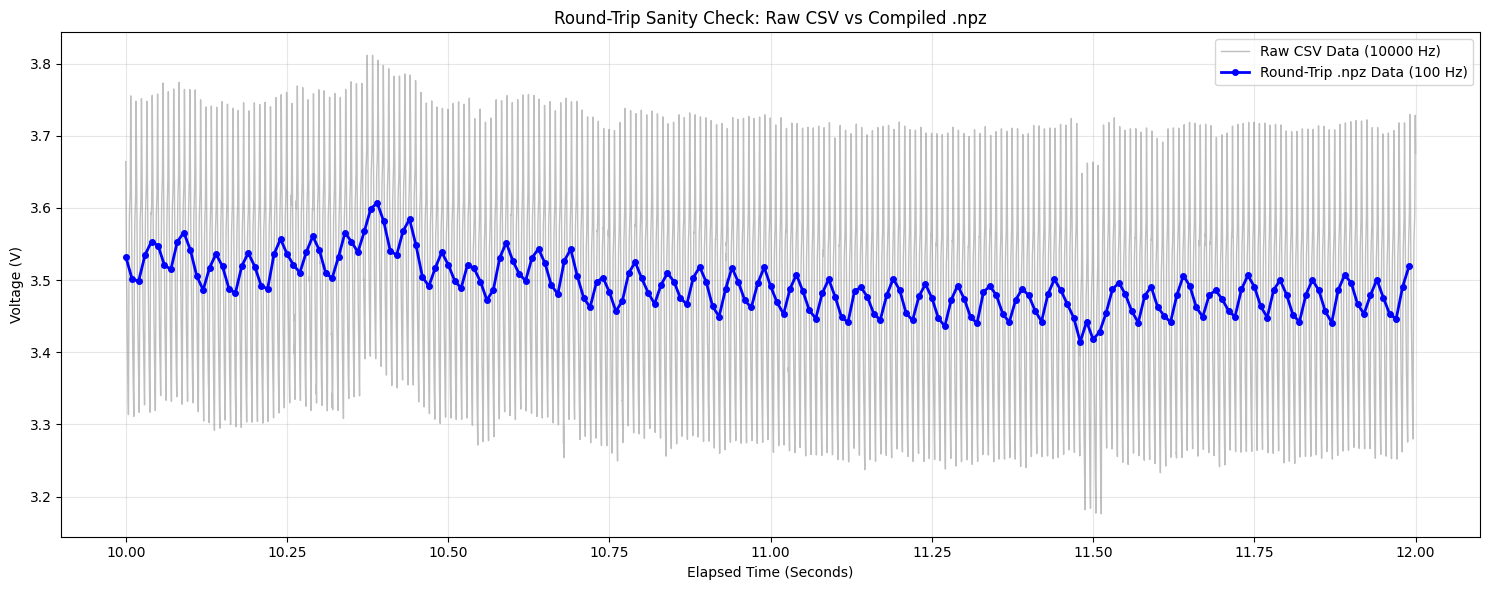

In [203]:
import re

def plot_sanity_check(raw_csv=None, npz_file=None, target_hz=100, offset_seconds=10, duration_seconds=2.0, npz_dir="preprocess_cache", csv_dir="data"):

    def we_can_rebuild_him(basis_file,new_dir,new_ext,strippattern='',addpattern=''):
        return os.path.join(
            new_dir,
            os.path.splitext(addpattern+re.sub(strippattern,'',os.path.basename(basis_file)))[0] + new_ext
        )

    if not raw_csv and not npz_file:
        raise ValueError("raw_csv or npz_file must be provided.")
    elif raw_csv:
        npz_file = we_can_rebuild_him(raw_csv, npz_dir, '.npz', strippattern='^light_')
    else:
        raw_csv = we_can_rebuild_him(npz_file, csv_dir, '.csv', addpattern='light_')

    # 1. Figure out native sample rate and load a chunk of RAW data
    native_hz = get_sample_rate(raw_csv)
    raw_df = downsample_with_pandas(raw_csv, 1, n_seconds=duration_seconds, skip_seconds=offset_seconds)

    # 2. Load the fully processed .npz Cache file
    print(f"Loading round-trip data from {npz_file}...")
    data = np.load(npz_file)
    npz_voltage = data['voltage']

    # Slice exactly the right number of downsampled items from the .npz array
    npz_samples_to_read = int(target_hz * duration_seconds)
    npz_sample_offset = int(offset_seconds * target_hz)
    npz_voltage_slice = npz_voltage[npz_sample_offset:npz_sample_offset+npz_samples_to_read]

    # 3. Reconstruct the time-axis for the .npz file so they overlay
    # We grab the starting time of the raw data and step by 1/target_hz
    t0 = raw_df['elapsed_s'].iloc[0]
    npz_time = t0 + (np.arange(len(npz_voltage_slice)) * (1.0 / target_hz))

    # 4. Plot them on top of each other
    plt.figure(figsize=(15, 6))

    # Plot raw data (Semi-transparent gray)
    plt.plot(raw_df['elapsed_s'], raw_df['voltage_V'],
             label=f'Raw CSV Data ({native_hz} Hz)',
             alpha=0.5, color='gray', linewidth=1)

    # Plot the round-trip .npz data (Thick blue line with dots)
    plt.plot(npz_time, npz_voltage_slice,
             label=f'Round-Trip .npz Data ({target_hz} Hz)',
             linewidth=2, color='blue', marker='o', markersize=4)

    plt.title(f"Round-Trip Sanity Check: Raw CSV vs Compiled .npz")
    plt.xlabel("Elapsed Time (Seconds)")
    plt.ylabel("Voltage (V)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_sanity_check(raw_csv="data\\light_20260501_031802_led_4-device_chicken_dance_10000_hz.csv", target_hz=downsample_target_hz)

#### Event coherency

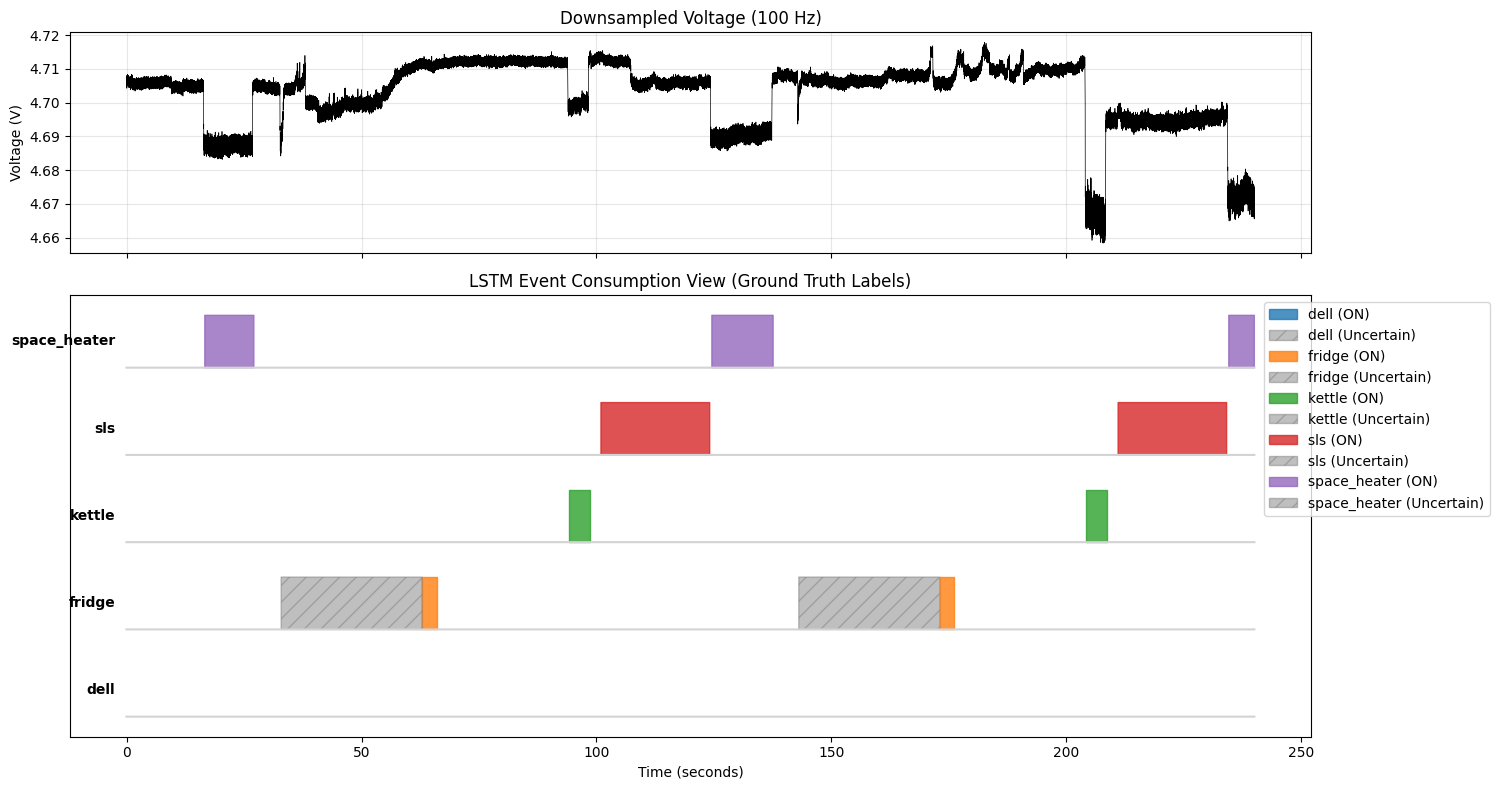

In [204]:
def plot_lstm_event_view(npz_file, start_sec=0, duration_sec=240, target_hz=100):
    """
    Plots a 4-minute window of the downsampled voltage and the state matrix
    exactly as the LSTM consumes it from the .npz cache.
    """
    # 1. Load the compiled ground truth
    data = np.load(npz_file)
    voltage = data['voltage']
    states = data['states']
    devices = data['devices']

    # 2. Calculate indices for the 4-minute window
    start_idx = int(start_sec * target_hz)
    end_idx = int((start_sec + duration_sec) * target_hz)

    # Prevent out-of-bounds errors if the file is shorter than 4 minutes
    end_idx = min(end_idx, len(voltage))
    actual_duration = (end_idx - start_idx) / target_hz

    # Slice the data arrays
    voltage_slice = voltage[start_idx:end_idx]
    states_slice = states[start_idx:end_idx]
    time_axis = np.arange(len(voltage_slice)) / target_hz + start_sec

    # 3. Setup the plots (Top: Voltage, Bottom: State Matrix)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2]})

    # --- TOP PLOT: Voltage ---
    ax1.plot(time_axis, voltage_slice, color='black', linewidth=0.5)
    ax1.set_title(f"Downsampled Voltage ({target_hz} Hz)")
    ax1.set_ylabel("Voltage (V)")
    ax1.grid(True, alpha=0.3)

    # --- BOTTOM PLOT: Device States ---
    colors = plt.cm.tab10.colors

    for i, dev in enumerate(devices):
        dev_state = states_slice[:, i]
        base_y = i * 2.0  # Offset each device vertically by 2 units so they don't overlap

        # Plot the baseline (OFF state)
        ax2.plot(time_axis, np.full_like(time_axis, base_y), color='lightgray', linestyle='-')

        # Fill blocks for ON (1.0)
        on_mask = (dev_state == 1.0)
        ax2.fill_between(time_axis, base_y, base_y + 1.2, where=on_mask,
                         color=colors[i % len(colors)], label=f"{dev} (ON)", alpha=0.8)

        # Fill blocks for UNCERTAIN (-1.0)
        uncertain_mask = (dev_state == -1.0)
        ax2.fill_between(time_axis, base_y, base_y + 1.2, where=uncertain_mask,
                         color='gray', alpha=0.5, hatch='//', label=f"{dev} (Uncertain)")

        # Print the device name directly on the Y-axis
        ax2.text(time_axis[0] - (actual_duration * 0.01), base_y + 0.6, dev,
                 ha='right', va='center', fontweight='bold', fontsize=10)

    # Clean up bottom plot
    ax2.set_yticks([])  # Hide the arbitrary Y numbers
    ax2.set_xlabel("Time (seconds)")
    ax2.set_title("LSTM Event Consumption View (Ground Truth Labels)")

    # Deduplicate the legend so we don't get 10,000 entries
    handles, labels = ax2.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax2.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.tight_layout()
    plt.show()

# Run it on one of your cached files
test_file = "preprocess_cache/20260501_023148_incandescent_4-device_serenade_20000_hz.npz"
plot_lstm_event_view(test_file, start_sec=0, duration_sec=240)

In [205]:
def calculate_pos_weights(loader, num_classes, device, max_weight=15):
    """
    Calculates the exact ratio of OFF vs ON windows for each class
    to dynamically balance the BCE loss function.

    device  --   computational device for where to put weights once complete
    """
    pos_counts = torch.zeros(num_classes)
    neg_counts = torch.zeros(num_classes)

    print("Scanning training data to calculate class weights...")
    for _, targets in loader:
        # We only count explicit 1.0 (ON) and 0.0 (OFF)
        pos_counts += (targets == 1.0).sum(dim=0)
        neg_counts += (targets == 0.0).sum(dim=0)

    # Prevent division by zero just in case a device has 0 positive windows
    pos_counts = torch.clamp(pos_counts, min=1.0)

    # pos_weight = (Number of Negatives) / (Number of Positives)
    pos_weights = neg_counts / pos_counts

    pos_weights = torch.clamp(pos_weights, max=max_weight)

    return pos_weights.to(device)


def train_model(train_loader, num_classes, num_epochs=5, learning_rate=0.001, device=Device, apply_weights=True):

    class_weights = None
    if apply_weights:
        class_weights = calculate_pos_weights(train_loader, num_classes, device)

    # Make sure we pass the dynamic number of classes we found in the data!
    model = BaselineLSTM(input_size=1, hidden_size=64, num_layers=2, num_classes=num_classes)
    model.to(device)

    criterion = nn.BCEWithLogitsLoss(reduction='none', pos_weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print("\n[*] Applied Positive Weights (Penalty multipliers for missing an ON event):")
    for i, dev in enumerate(classes):
        print(f"  - {dev}: {class_weights[i].item():.2f}x punishment")

    print("\n[*] Beginning Training Loop...")

    # 4. The Epoch Loop
    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            mask = (targets == -1).bool() # find grey areas
            target_as_on = torch.abs(targets)

            raw_loss = criterion(outputs, target_as_on)
            with torch.no_grad():
                predicting_off = (outputs < 0).bool()
                forgive_mask = mask & predicting_off

            raw_loss[forgive_mask] = 0.0
            loss = raw_loss.mean()
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

            optimizer.step()

            running_loss += loss.item()

            # Print a progress update every 100 batches
            if (batch_idx + 1) % 100 == 0:
                avg_loss = running_loss / 100
                print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {avg_loss:.4f}")
                running_loss = 0.0

    print("[+] Training Complete!")
    return model

## Training

In [206]:
print(f"[*] Tracking {len(classes)} devices: {classes}")

# Fire up the training loop!
trained_model = train_model(train_loader, num_classes=len(classes), num_epochs=3)

[*] Tracking 5 devices: ['dell' 'fridge' 'kettle' 'sls' 'space_heater']
Scanning training data to calculate class weights...

[*] Applied Positive Weights (Penalty multipliers for missing an ON event):
  - dell: 3.78x punishment
  - fridge: 15.00x punishment
  - kettle: 15.00x punishment
  - sls: 10.91x punishment
  - space_heater: 11.16x punishment

[*] Beginning Training Loop...
Epoch [1/3] | Batch [100/9189] | Loss: 0.8412
Epoch [1/3] | Batch [200/9189] | Loss: 0.6515
Epoch [1/3] | Batch [300/9189] | Loss: 0.5918
Epoch [1/3] | Batch [400/9189] | Loss: 0.8064
Epoch [1/3] | Batch [500/9189] | Loss: 0.6000
Epoch [1/3] | Batch [600/9189] | Loss: 0.5027
Epoch [1/3] | Batch [700/9189] | Loss: 0.4757
Epoch [1/3] | Batch [800/9189] | Loss: 0.5441
Epoch [1/3] | Batch [900/9189] | Loss: 0.5937
Epoch [1/3] | Batch [1000/9189] | Loss: 0.4838
Epoch [1/3] | Batch [1100/9189] | Loss: 0.4874
Epoch [1/3] | Batch [1200/9189] | Loss: 0.4648
Epoch [1/3] | Batch [1300/9189] | Loss: 0.4461
Epoch [1/3] | 

## Post-training setup

In [168]:
import torch

def test_on_unseen_file(model, file_path, classes):
    model.eval() # Set to evaluation mode
    test_dataset = FastNILMDataset(file_path, window_size=5000)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    all_preds = []
    all_targets = []

    print(f"[*] Testing on: {file_path}")
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(Device)
            outputs = model(inputs)

            # Convert logits to probabilities (0 to 1)
            probs = torch.sigmoid(outputs)
            all_preds.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Concatenate results
    predictions = np.vstack(all_preds)
    actuals = np.vstack(all_targets)

    # Simple threshold: > 0.5 means the model thinks it's ON
    binary_preds = (predictions > 0.5).astype(int)

    # Print accuracy for each device
    for i, device_name in enumerate(classes):
        # We only look at actual 0 and 1 (ignore the -1 uncertainty for basic accuracy)
        mask = (actuals[:, i] != -1)
        correct = (binary_preds[mask, i] == actuals[mask, i]).sum()
        total = mask.sum()
        print(f" - {device_name}: {100 * correct/total:.2f}% Accuracy")


def evaluate_thresholds(model, loader, device, classes, thresholds=[0.5, 0.7, 0.85, 0.9, 0.95]):
    model.eval()
    all_probs = []
    all_targets = []

    print("[*] Running inference to collect raw probabilities...")
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            # Get raw logits, then apply sigmoid to get probabilities (0.0 to 1.0)
            logits = model(inputs)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu())
            all_targets.append(targets.cpu())

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # Identify the indices where the ground truth is "All OFF"
    # (Sum of targets across devices is 0)
    is_actually_all_off = (all_targets.sum(dim=1) == 0)

    print("\n=======================================================")
    print("                 THRESHOLD SWEEP RESULTS               ")
    print("=======================================================")

    for thresh in thresholds:
        # 1. Apply the threshold to get binary predictions
        preds = (all_probs >= thresh).float()

        # 2. Calculate "All OFF" stats
        predicted_anything = (preds.sum(dim=1) > 0)
        true_all_off = (is_actually_all_off & ~predicted_anything).sum().item()
        false_alarms = (is_actually_all_off & predicted_anything).sum().item()

        print(f"\n--- Threshold: {thresh:.2f} ---")
        print(f"[*] 'All OFF' Accuracy:")
        print(f"    - Correctly quiet: {true_all_off}")
        print(f"    - False positives: {false_alarms}")
        print(f"[*] True Positives (Caught Events):")

        # 3. Calculate True Positives for each specific device
        for i, dev in enumerate(classes):
            tp = ((preds[:, i] == 1.0) & (all_targets[:, i] == 1.0)).sum().item()
            # Also calculate total actual events for context
            actual_events = (all_targets[:, i] == 1.0).sum().item()

            # Avoid division by zero
            recall_pct = (tp / actual_events * 100) if actual_events > 0 else 0
            print(f"    - {dev}: {tp} / {actual_events} ({recall_pct:.1f}% recall)")


from scipy.signal import medfilt

def evaluate_with_smoothing(model, loader, device, classes, threshold=0.5, filter_size=3):
    """
    filter_size: Must be an odd number. A size of 5 means the filter looks at
                 2 windows before and 2 windows after the current prediction.
    """
    model.eval()
    all_probs = []
    all_targets = []

    print(f"[*] Running inference to collect sequential predictions...")
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Combine into continuous numpy arrays
    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # 1. Apply initial threshold to get raw, noisy binary predictions
    raw_preds = (all_probs >= threshold).astype(float)
    smoothed_preds = np.zeros_like(raw_preds)

    # 2. Apply Median Smoothing to each device independently
    print(f"[*] Applying Median Filter (size={filter_size}) to smooth out transient noise...")
    for i in range(len(classes)):
        # medfilt requires an odd kernel size
        smoothed_preds[:, i] = medfilt(raw_preds[:, i], kernel_size=filter_size)

    # 3. Calculate Stats on the SMOOTHED predictions
    is_actually_all_off = (all_targets.sum(axis=1) == 0)
    predicted_anything = (smoothed_preds.sum(axis=1) > 0)

    true_all_off = (is_actually_all_off & ~predicted_anything).sum()
    false_alarms = (is_actually_all_off & predicted_anything).sum()

    print("\n=======================================================")
    print(f"       SMOOTHED RESULTS (Thresh: {threshold}, Filter: {filter_size})")
    print("=======================================================")
    print(f"[*] 'All OFF' Accuracy:")
    print(f"    - Correctly quiet: {true_all_off}")
    print(f"    - Ghosts (False Alarms): {false_alarms}")
    print(f"[*] True Positives (Caught Events):")

    for i, dev in enumerate(classes):
        tp = ((smoothed_preds[:, i] == 1.0) & (all_targets[:, i] == 1.0)).sum()
        actual_events = (all_targets[:, i] == 1.0).sum()

        recall_pct = (tp / actual_events * 100) if actual_events > 0 else 0
        print(f"    - {dev}: {tp} / {actual_events} ({recall_pct:.1f}% recall)")

    return smoothed_preds, all_targets



In [169]:
smoothed_preds, targets = evaluate_with_smoothing(trained_model, test_loader, Device, classes, threshold=0.5, filter_size=5)

# Run the sweep!
evaluate_thresholds(trained_model, test_loader, Device, classes)

[*] Running inference to collect sequential predictions...
[*] Applying Median Filter (size=5) to smooth out transient noise...

       SMOOTHED RESULTS (Thresh: 0.5, Filter: 5)
[*] 'All OFF' Accuracy:
    - Correctly quiet: 0
    - Ghosts (False Alarms): 154006
[*] True Positives (Caught Events):
    - dell: 7972 / 77490 (10.3% recall)
    - fridge: 280 / 650 (43.1% recall)
    - kettle: 13071 / 18000 (72.6% recall)
    - sls: 0 / 0 (0.0% recall)
    - space_heater: 6310 / 18370 (34.3% recall)
[*] Running inference to collect raw probabilities...

                 THRESHOLD SWEEP RESULTS               

--- Threshold: 0.50 ---
[*] 'All OFF' Accuracy:
    - Correctly quiet: 0
    - False positives: 154006
[*] True Positives (Caught Events):
    - dell: 7981 / 77490 (10.3% recall)
    - fridge: 280 / 650 (43.1% recall)
    - kettle: 13088 / 18000 (72.7% recall)
    - sls: 0 / 0 (0.0% recall)
    - space_heater: 6315 / 18370 (34.4% recall)

--- Threshold: 0.70 ---
[*] 'All OFF' Accuracy:

## Testing

In [207]:
test_file = "preprocess_cache/20260501_023148_incandescent_4-device_serenade_20000_hz.npz"
test_on_unseen_file(trained_model, test_file, classes)

[*] Testing on: preprocess_cache/20260501_023148_incandescent_4-device_serenade_20000_hz.npz
 - dell: 100.00% Accuracy
 - fridge: 96.92% Accuracy
 - kettle: 93.95% Accuracy
 - sls: 31.46% Accuracy
 - space_heater: 91.52% Accuracy


[*] Fridge event found! Use start_idx=3194


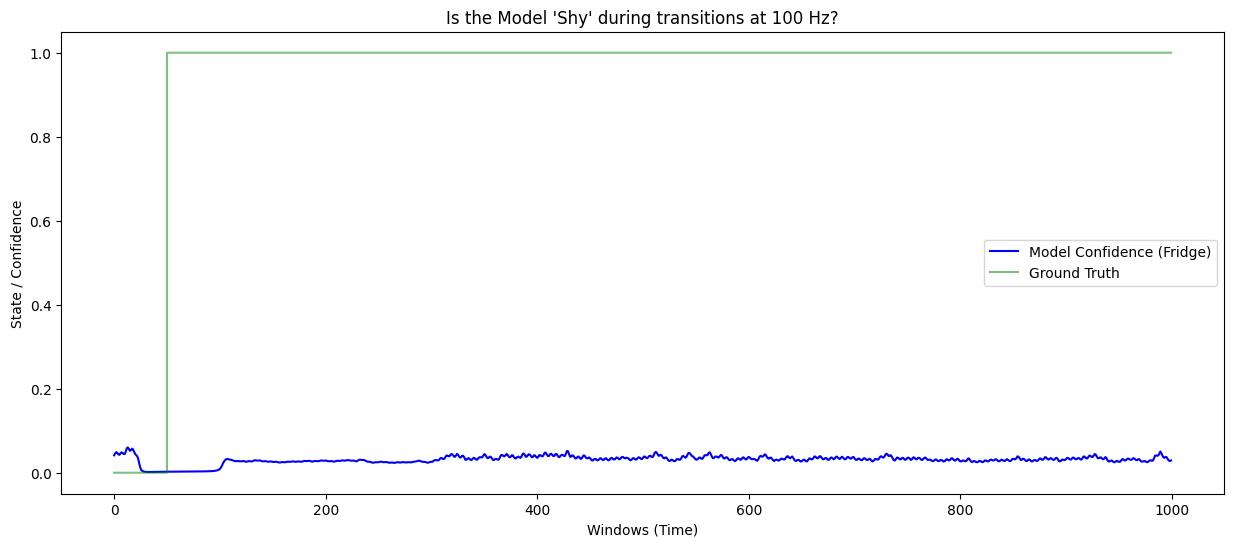

['dell' 'fridge' 'kettle' 'sls' 'space_heater']


In [ ]:
def plot_predictions(model, dataset, start_idx, length=1000):
    model.eval()
    voltages = []
    preds = []
    truths = []

    for i in range(start_idx, start_idx + length):
        x, y = dataset[i]
        with torch.no_grad():
            # Note: Ensure 'device' matches your global device variable
            logit = model(x.unsqueeze(0).to(Device))
            prob = torch.sigmoid(logit).cpu().numpy()[0]

        # Grab the last voltage point in the window for plotting
        voltages.append(x[-1].item())
        preds.append(prob) # This is a vector of probabilities
        truths.append(y.numpy())

    preds = np.array(preds)
    truths = np.array(truths)

    # Create an explicit X-axis for plt.step
    time_steps = np.arange(length)

    # Plotting Fridge (index 1 based on your list)
    plt.figure(figsize=(15, 6))

    # Provide time_steps as X, and the data as Y
    plt.plot(time_steps, preds[:, 1], label="Model Confidence (Fridge)", color='blue')
    plt.step(time_steps, np.abs(truths[:, 1]), label="Ground Truth", where='post', color='green', alpha=0.5)

    plt.title(f"Is the Model 'Shy' during transitions at {downsample_target_hz} Hz?")
    plt.xlabel("Windows (Time)")
    plt.ylabel("State / Confidence")
    plt.legend()
    plt.show()

# 1 is the index for the Fridge. Change it if your classes list has it elsewhere.
fridge_class_idx = 1

# Scan for the first moment the fridge isn't 0 (either 1.0 or -1.0)
found_idx = None
for i in range(len(test_dataset)):
    _, y = test_dataset[i]
    if y[fridge_class_idx] != 0.0:
        # Step back 50 windows so we can see the lead-up to the event
        found_idx = max(0, i - 50)
        print(f"[*] Fridge event found! Use start_idx={found_idx}")
        break

if found_idx is None:
    print("No Fridge events found in this dataset.")
else:
    plot_predictions(trained_model, test_dataset, start_idx=found_idx)

print(classes)

In [209]:
def count_device_events(dataset, device_idx, dataset_name="Dataset"):
    on_count = 0
    uncertain_count = 0

    for i in range(len(dataset)):
        _, y = dataset[i]
        val = y[device_idx].item()

        if val == 1.0:
            on_count += 1
        elif val == -1.0:
            uncertain_count += 1

    print(f"[{dataset_name}] Fridge ON windows: {on_count} | Uncertain windows: {uncertain_count}")
    return on_count

# Make sure this matches your actual classes list!
fridge_idx = classes.tolist().index('fridge') if isinstance(classes, np.ndarray) else classes.index('fridge')

print(f"[*] Scanning for Fridge (Index {fridge_idx})...")
count_device_events(train_dataset, fridge_idx, "Train Set")
count_device_events(test_dataset, fridge_idx, "Test Set")

[*] Scanning for Fridge (Index 1)...
[Train Set] Fridge ON windows: 940 | Uncertain windows: 9000
[Test Set] Fridge ON windows: 2321 | Uncertain windows: 39040


2321

### Confusion matrix

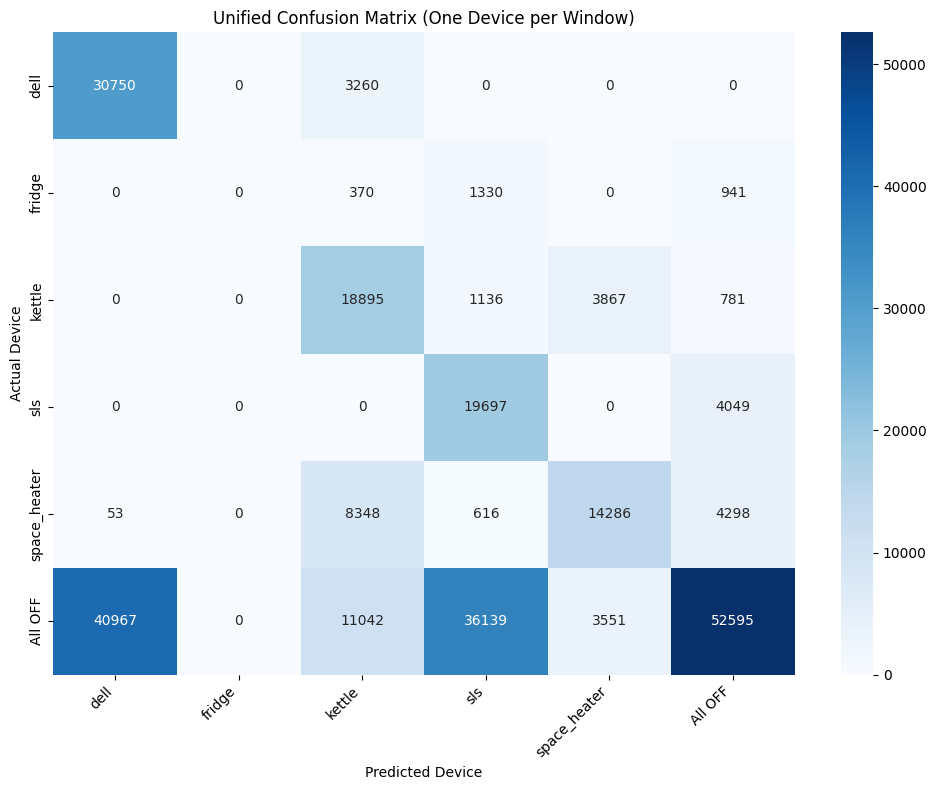

In [213]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_unified_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs.to(Device))
            all_preds.append(outputs.cpu().numpy()) # Keep raw logits
            all_targets.append(targets.cpu().numpy())

    preds_flat = np.vstack(all_preds)
    targets_flat = np.vstack(all_targets)

    # 1. Filter out ANY window that contains a -1 (Uncertainty)
    valid_mask = ~np.any(targets_flat == -1, axis=1)
    y_true_clean = targets_flat[valid_mask]
    y_pred_clean = preds_flat[valid_mask]

    # 2. Add an "All OFF" class at the end
    extended_classes = list(classes) + ['All OFF']
    off_index = len(classes)

    # 3. Convert Ground Truth to single integer classes
    # If the row sum is 0, it's "All OFF". Otherwise, it's the argmax (the 1.0)
    y_true_idx = np.where(y_true_clean.sum(axis=1) == 0,
                          off_index,
                          np.argmax(y_true_clean, axis=1))

    # 4. Convert Predictions to single integer classes
    # If the highest logit is <= 0 (model thinks everything is OFF), map to "All OFF"
    # Otherwise, pick the device with the highest confidence
    y_pred_idx = np.where(np.max(y_pred_clean, axis=1) <= 0,
                          off_index,
                          np.argmax(y_pred_clean, axis=1))

    # 5. Generate the NxN Confusion Matrix
    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=range(len(extended_classes)))

    # 6. Plot it!
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=extended_classes,
                yticklabels=extended_classes)
    plt.title("Unified Confusion Matrix (One Device per Window)")
    plt.ylabel('Actual Device')
    plt.xlabel('Predicted Device')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# plot_unified_confusion_matrix(trained_model, test_loader, classes)
Image("visualizations\\lstm_confusion_matrix_micro_files_weighted_capped_3_epochs_globally_z_normalized.png")